# Conversão de `main.py` para Jupyter Notebook

## 1) Imports e configurações iniciais

In [ ]:
import importlib
from utils import encontrar_pdfs, regra_divisao, destaca_tabelas, crop_page
# importlib.reload(utils)
from leitor_pdf import dividir_pdf
import pdfplumber, json
import utils
import json
import cv2
import numpy as np
from IPython.display import display
from PIL import Image

print("Imports carregados")


## 2) Listar PDFs e iterar sobre eles

In [ ]:
pdf_folder = "arquivos"

pdfs_encontrados = [f for f in encontrar_pdfs(pdf_folder) if f.lower().endswith(".pdf")]
print(f"Encontrados {len(pdfs_encontrados)} PDFs em {pdf_folder}")
for arquivo in pdfs_encontrados:
    print("-", arquivo)


In [ ]:
idx = 0
arquivo = pdfs_encontrados[idx]
print(f"Analisando: {arquivo}")

## 3) Processar cada PDF (célula principal)

In [ ]:
def extrair_texto_pagina(pagina):
    largura = pagina.width
    altura = pagina.height-32 # cortar rodapé

    coluna_esquerda = pagina.crop((0, 0, largura/2, altura))
    coluna_direita = pagina.crop((largura/2, 0, largura, altura))

    return coluna_esquerda.extract_text_lines() + coluna_direita.extract_text_lines()
    

In [ ]:
def table_extractor(page):
     for l in page.extract_text_lines():
          if "Tabela" in l['text']:
               cab = int(l['top'])-5
     
     cropped = page.crop((0, cab, page.width, page.height))
     
     if cropped.rect_edges == []:
          return None, None

     h_lines = []
     v_lines = []
     for r in cropped.rect_edges:
          # display(cropped.to_image(100).draw_circle((int(r['x1']), int(r['bottom'])), radius=5, stroke="red", fill="white"))
          h_lines.append(int(r['bottom']))
          v_lines.append(int(r['x1']))

     distancias = []
     for i, h in enumerate(h_lines):
          if i < (len(h_lines)-1) and (i%8==0):
               distancias.append(h_lines[i+1]-h)
               
     # print(max(distancias))
     mesq = int(cropped.rect_edges[0]['x0'])
     rod = page.height
     
     cropped = page.crop((mesq, cab, v_lines[-1], rod))
     for l in cropped.extract_text_lines():
          if "Tabela" in l['text']:
               nomesTabelas = (l['text'][l['text'].find("Tabela"):])
          if (l['chars'][0]['text'] == '*') or (int(l['chars'][0]['size']) < int(l['chars'][1]['size'])):# or (cropped.extract_text_lines()[-1]['bottom'] <= h_lines[-1]):
               rod = h_lines[-1]
          elif ((int(l['chars'][0]['bottom']) >= (h_lines[-1]-1)) and (int(l['chars'][0]['bottom']) - (h_lines[-1]-1)) < (sum(distancias)/len(distancias))):
               rod = (l['chars'][0]['bottom']+2)
               h_lines.append(l['chars'][0]['bottom']+2)

     cropped = page.crop((mesq, cab, v_lines[-1], rod))

     table_settings = {
          "vertical_strategy": "explicit",
          "horizontal_strategy": "explicit",
          "explicit_vertical_lines": v_lines,
          "explicit_horizontal_lines": h_lines
     }
     display(page.to_image(50))
     display(cropped.to_image(100).debug_tablefinder(table_settings))
     return cropped.extract_tables(table_settings), nomesTabelas

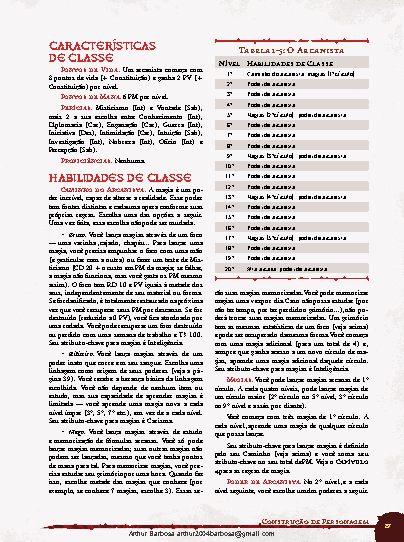

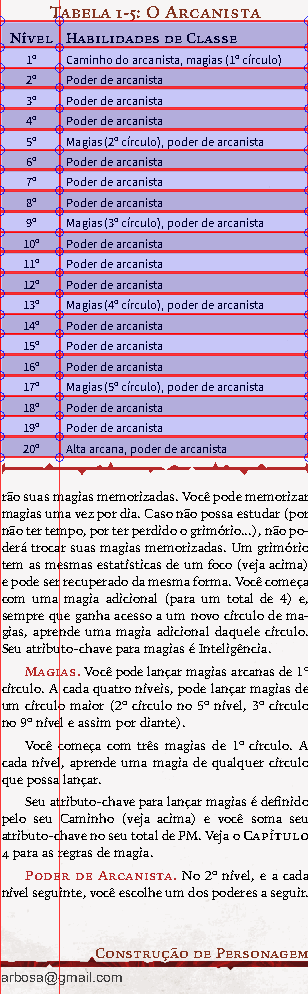

In [349]:
with pdfplumber.open(arquivo) as pdf:
   page = pdf.pages[42]
   table, nome_table = table_extractor(page)

In [ ]:
with pdfplumber.open(arquivo) as pdf:
        for pagina_idx, page in enumerate(pdf.pages):
                page = pdf.pages[pagina_idx]
                        
                if page.rect_edges != []:
                        tem_tabela = False
                        nomesTabelas=[]
                        for l in page.extract_text_lines():
                                if "Tabela" in l['text']:
                                        tem_tabela=True
                                        nomesTabelas.append(l['text'])

                                        table, nome_table = table_extractor(page)
                                        if (table and nome_table) != None:
                                                print(page)
                                                print(nome_table)
                                                print(table)

In [ ]:
from IPython.display import display


with pdfplumber.open(arquivo) as pdf:
        # for pagina_idx, page in enumerate(pdf.pages):
                page = pdf.pages[37]
                pagina_completa = extrair_texto_pagina(page)
                tem_tabela = False
                nomesTabelas=[]
                for linha in pagina_completa:
                        if "Tabela" in linha['text']: 
                                tem_tabela=True

                        
                if tem_tabela: 
                        cropped = destaca_tabelas(page)
                        if cropped != None: 
                                print(page)
                                t, pt, ts = tabela_extrator(cropped)
                                display(t.to_image(150).debug_tablefinder(table_settings=ts))
                                for linha in cropped.extract_text_lines():
                                        if "Tabela" in linha['text']:
                                                nomesTabelas.append(linha['text'])
                                                print(linha['text'])
                                                table = extrair_tabelas(cropped)
                                                # with open(f"{linha['text']}.json", 'w', encoding='utf-8') as f:
                                                #         json.dump({tab[0]: tab[1].replace('\n', ' ') for tab in table}, f, ensure_ascii=False)
                                display(cropped.to_image(100))
                                print(table)
                                print("\n")

In [ ]:
racas = {raca[0]: raca[1].replace('\n', ' ') for raca in table}
with open('racas.json', 'w', encoding='utf-8') as racas_json:
    json.dump(racas, racas_json, indent=4, ensure_ascii=False)
    print(racas)
    print(json.dumps(racas, ensure_ascii=False))

In [ ]:
# Iterar sobre as linhas extraídas e detectar padrões
largura = page.width
altura = page.height-32 # cortar rodapé

coluna_esquerda = page.crop((0, 0, largura/2, altura))
coluna_direita = page.crop((largura/2, 0, largura, altura))

pagina_completa = coluna_esquerda.extract_text_lines() + coluna_direita.extract_text_lines()

for linha in pagina_completa:
    R, G, B = (
        linha["chars"][0]["non_stroking_color"][0],
        linha["chars"][0]["non_stroking_color"][1],
        linha["chars"][0]["non_stroking_color"][2],
    )
    tam_fonte = linha["chars"][0]["size"]

    params_title = all(pixel_color * 255 > 200 for pixel_color in (R, G, B)) and tam_fonte >= 15

    # if "Tabela" in linha["text"]:
    #     list_tabela = Tabela(linha["text"], tam_fonte, [R, G, B])
    #     print(linha["chars"][0])

    if params_title: print(linha['text']) 
    # if (params_title):
    #     print(linha['text'])
    #     print(tam_fonte)

